# sde_model.ipynb

Initial model for the governing SDE. Keep in mind layers are low, since this is a "hackathon" project.

### Initial instructions

- Make sure to have a ```.venv``` set up. Install ```torch```, ```torchsde```, ```numpy```, ```matplotlib```. 

#### Package imports

In [7]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

Priority: mps (Apple Silicon) > CUDA > CPU

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


#### Synthetic data generation (just in case)

In [12]:
def generate_synthetic_flight(num_steps=100):
    t = torch.linspace(0, 1, num_steps).to(device)
    # Synthetic ground truth: Linear fuel burn, constant velocity, slight climb
    # Shape: [Time, 3] -> [Fuel, Velocity, Altitude]
    fuel = 1.0 - 0.2 * t 
    velocity = 0.8 + 0.05 * torch.sin(5 * t)
    altitude = 0.5 + 0.3 * t
    
    y_true = torch.stack([fuel, velocity, altitude], dim=-1).unsqueeze(1) # [T, Batch=1, 3]
    return t, y_true

#### Load flight tensors

In [2]:
def load_flight_tensors(file_path="../Datasets/flight_data.pt", device="cpu"):
    data = torch.load(file_path, map_location=device)
    
    t = data['t'].to(device)
    y_true = data['y_true'].to(device)
    stats = data['stats']
    
    return t, y_true, stats

#### NeuralSDE class

In [5]:
class NeuralSDE(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        # Input: [Fuel Flow, Velocity, Altitude]
        self.input_dim = 3
        
        # Drift (deterministic) - Predicts the change in states
        self.f_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3)
        )
        
        # Diffusion (stochastic) - Predicts the noise magnitude
        self.g_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
            nn.Sigmoid() # Keeps standard deviation positive and bounded [0, 1]
        )

        # 1. Apply general initialization FIRST
        def init_weights(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.01)

        self.f_net.apply(init_weights)
        self.g_net.apply(init_weights)

        # 2. Apply specific final-layer initializations AFTER
        # Initialize drift to output small values initially
        nn.init.constant_(self.f_net[-1].weight, 0.01)
        nn.init.constant_(self.f_net[-1].bias, 0.0)
        
        # Initialize diffusion to output very small noise initially
        nn.init.constant_(self.g_net[-2].weight, 0.001)
        nn.init.constant_(self.g_net[-2].bias, 0.0)
        
        self.noise_type = "diagonal"
        self.sde_type = "ito"

    def f(self, t, y):
        # y shape: [batch_size, 3]
        # Since we use fuel flow, velocity, and altitude, all can increase or decrease.
        # No physical gates needed!
        return self.f_net(y)

    def g(self, t, y):
        # y shape: [batch_size, 3]
        return self.g_net(y)

#### Training

In [14]:
def train_step(model, batch_y0, batch_t, batch_y_true, optimizer):
    model.train()
    optimizer.zero_grad()    
    
    # Integramos la SDE
    pred_y = torchsde.sdeint_adjoint(model, batch_y0, batch_t, dt=0.01, method='euler')
    
    # Loss Function (MSE)
    loss = nn.MSELoss()(pred_y, batch_y_true)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    return loss.item()

def train_model(model, t, y_true, epochs=500):
    # Quédate solo con AdamW para Neural SDEs
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-1, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5,threshold=0.01) 
    
    y0 = y_true[0].to(device)
    t = t.to(device)
    y_true = y_true.to(device)

    for epoch in range(1, epochs + 1):
        loss = train_step(model, y0, t, y_true, optimizer)
        scheduler.step(loss)
        
        if epoch % 20 == 0 or epoch == 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | Loss: {loss:.6f} | LR: {current_lr:.6f}")

    return model

#### Actually running the code

In [17]:
t, y_true, stats = load_flight_tensors("../Data/Datasets/flight_data.pt", device)
model = NeuralSDE(hidden_dim=64).to(device)
trained_model = train_model(model, t, y_true, epochs=500)

Epoch 001 | Loss: 0.314024 | LR: 0.100000
Epoch 020 | Loss: 0.050907 | LR: 0.100000


KeyboardInterrupt: 

# Codigo de prueba (6 variables)


In [ ]:
import torch
import torch.nn as nn
import torchsde
import numpy as np

# 1. FUNCIÓN DE CARGA SEGURA
def load_flight_tensors(file_path="../Datasets/flight_data.pt", device="cpu"):
    data = torch.load(file_path, map_location='cpu') 
    y_true = data['y_true']
    t = data['t'].to(device)
    stats = data['stats']
    
    nan_mask = torch.isnan(y_true)
    flights_with_nans = torch.any(nan_mask, dim=(0, 2))
    valid_flights_idx = torch.where(~flights_with_nans)[0]
    
    y_clean = y_true[:, valid_flights_idx, :].to(device)
    print(f"Dataset cargado: {y_clean.shape[1]} vuelos impecables.")
    return t, y_clean, stats

# 2. ARQUITECTURA SDE (CORREGIDA PARA EVITAR NaNs)
class NeuralSDE(nn.Module):
    def __init__(self, hidden_dim=128): 
        super().__init__()
        self.input_dim = 6 
        
        self.f_net = nn.Sequential(
            nn.Linear(6, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 6)
        )
        
        self.g_net = nn.Sequential(
            nn.Linear(6, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 6),
            nn.Sigmoid() # Mantiene la desviación estándar en [0, 1]
        )

        # Inicialización general
        def init_weights(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                m.bias.data.fill_(0.01)

        self.f_net.apply(init_weights)
        self.g_net.apply(init_weights)

        # Inicialización de la Deriva (Casi estática)
        nn.init.constant_(self.f_net[-1].weight, 0.001)
        nn.init.constant_(self.f_net[-1].bias, 0.0)
        
        # LA CLAVE PARA EVITAR EL NaN: Inicialización de la Difusión (Ruido)
        nn.init.constant_(self.g_net[-2].weight, 0.001) 
        # Sigmoid(-5.0) ≈ 0.006. Esto ahoga el ruido inicial para que no explote.
        nn.init.constant_(self.g_net[-2].bias, -5.0) 
        
        self.noise_type = "diagonal"
        self.sde_type = "ito"

    def f(self, t, y):
        return self.f_net(y)

    def g(self, t, y):
        # Asegurar un ruido mínimo por seguridad numérica (clipping)
        return torch.clamp(self.g_net(y), min=1e-4)

# 3. FUNCIONES DE ENTRENAMIENTO (CON PASO MÁS CORTO)
def train_step(model, batch_y0, batch_t, batch_y_true, optimizer):
    model.train()
    optimizer.zero_grad()    
    
    # Reducimos el dt de 0.01 a 0.005 para mayor estabilidad
    pred_y = torchsde.sdeint_adjoint(model, batch_y0, batch_t, dt=0.005, method='euler')
    
    loss = nn.MSELoss()(pred_y, batch_y_true)
    loss.backward()
    
    # Recortar gradientes muy bruscamente para prevenir explosiones (Gradient Clipping)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
    
    optimizer.step()
    return loss.item()

def train_model(model, t, y_true, epochs=800):
    # LR reducido a 5e-4
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=15, factor=0.5, threshold=0.001
    ) 
    
    y0 = y_true[0]

    for epoch in range(1, epochs + 1):
        loss = train_step(model, y0, t, y_true, optimizer)
        
        # Si explota, paramos para no perder el tiempo
        if np.isnan(loss):
            print(f"❌ ERROR: El loss explotó a NaN en la Época {epoch}.")
            return model
            
        scheduler.step(loss)
        
        if epoch % 25 == 0 or epoch == 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Época {epoch:03d}/{epochs} | Loss: {loss:.6f} | LR: {current_lr:.6f}")

    return model

# ==========================================
# 4. EJECUTAR ENTRENAMIENTO
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Cargar el Train
t_train, y_true_train, stats = load_flight_tensors("/home/edgar/GitHub/StochasticATM/Data/Datasets/flight_data.pt", device)

# Instanciar y Entrenar
model = NeuralSDE(hidden_dim=128).to(device)
print("Iniciando entrenamiento...")
trained_model = train_model(model, t_train, y_true_train, epochs=100)

Usando dispositivo: cpu
Dataset cargado: 287 vuelos impecables.
Iniciando entrenamiento...
Época 001/800 | Loss: 0.135721 | LR: 0.000500


#### Uncertainty cone (for display)

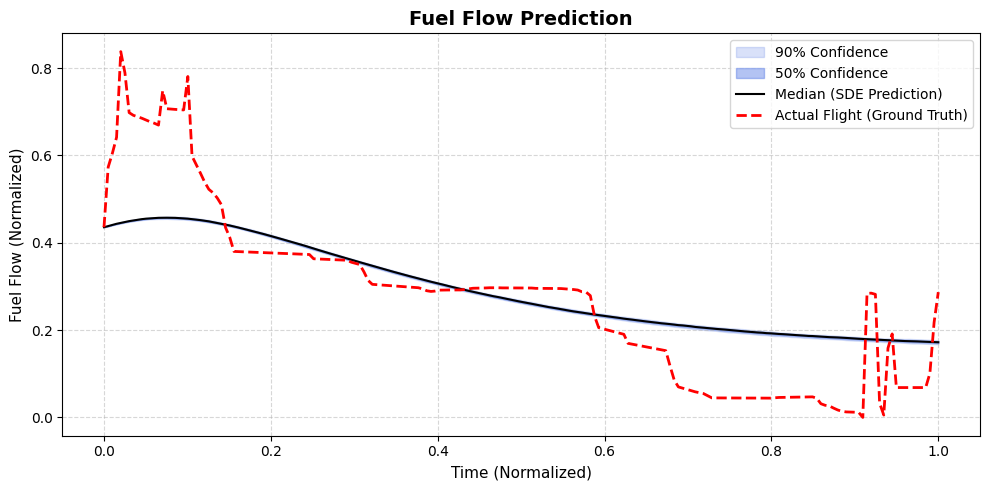

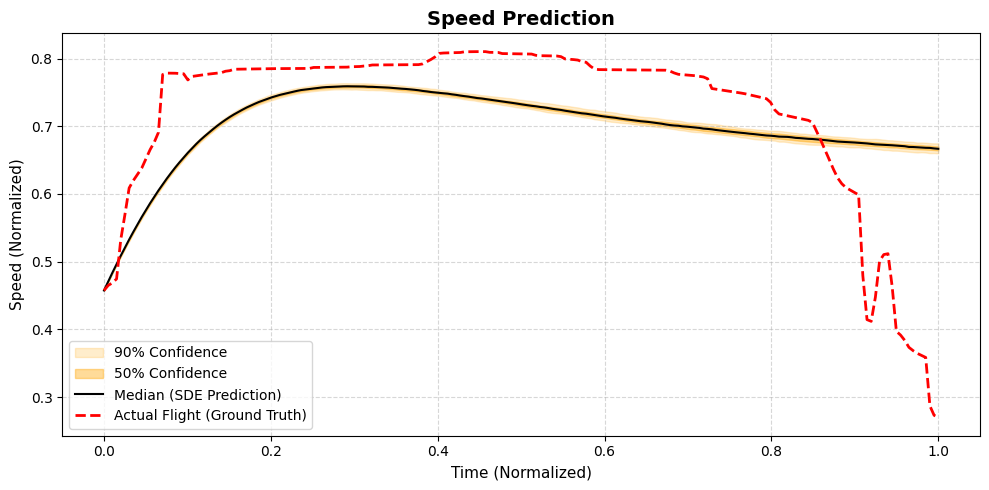

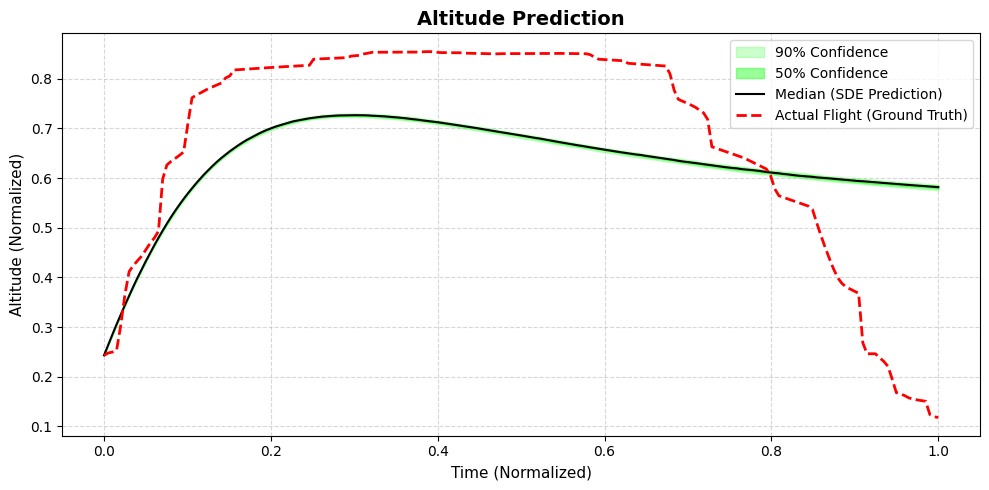

In [21]:
# 1. Cargar el dataset de test (Asegúrate de que la ruta sea correcta)
t_test, y_true_test, stats_test = load_flight_tensors("/home/edgar/GitHub/StochasticATM/Data/Datasets/flight_data_test.pt", device)

def generate_uncertainty_cone(model, y0, t_span, num_simulations=100):
    model.eval()
    with torch.no_grad():
        # y0 viene como [1, 6], lo repetimos para tener 100 simulaciones distintas
        # y0_expanded shape: [100, 6]
        y0_expanded = y0.repeat(num_simulations, 1).to(device)
        t_span = t_span.to(device)
        
        # Simulamos los 100 vuelos a la vez
        trajectories = torchsde.sdeint(model, y0_expanded, t_span, method='euler')
        
    return trajectories.cpu()

def plot_fan_chart(trajectories, t_span, y_true, feat_idx, title, ylabel, color):
    # Extraer datos de la característica específica
    # trajectories: [Time, Simulations, Features]
    data = trajectories[:, :, feat_idx].numpy()
    t = t_span.cpu().numpy()
    
    # Ground truth: [Time, 1, Features]
    true_val = y_true[:, 0, feat_idx].cpu().numpy()

    median = np.median(data, axis=1)
    p5, p25 = np.percentile(data, 5, axis=1), np.percentile(data, 25, axis=1)
    p75, p95 = np.percentile(data, 75, axis=1), np.percentile(data, 95, axis=1)

    plt.figure(figsize=(10, 5), dpi=100)
    
    plt.fill_between(t, p5, p95, color=color, alpha=0.2, label='90% Confidence')
    plt.fill_between(t, p25, p75, color=color, alpha=0.4, label='50% Confidence')
    plt.plot(t, median, color='black', lw=1.5, label='Median (SDE Prediction)')
    
    # Plot Ground Truth (Lo que pasó de verdad)
    plt.plot(t, true_val, color='red', lw=2, linestyle='--', label='Actual Flight (Ground Truth)')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Time (Normalized)", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# --- Ejecución de las gráficas ---
num_scenarios = 100 

# Tomamos el estado inicial COMPLETO (las 6 variables en el t=0)
# y_true_test[0] tiene forma [1, 6]
y0_test = y_true_test[0]

# Generamos las trayectorias
trajectories_test = generate_uncertainty_cone(model, y0_test, t_test, num_simulations=num_scenarios)

# Graficamos las 3 variables principales usando sus nuevos índices
# Index 0: Fuel Flow, Index 1: Velocity, Index 2: Altitude
plot_fan_chart(trajectories_test, t_test, y_true_test, 0, 
               "Fuel Flow Prediction", "Fuel Flow (Normalized)", "royalblue")

plot_fan_chart(trajectories_test, t_test, y_true_test, 1, 
               "Speed Prediction", "Speed (Normalized)", "orange")

plot_fan_chart(trajectories_test, t_test, y_true_test, 2, 
               "Altitude Prediction", "Altitude (Normalized)", "lime")